Title: "To Predict and Analyse Human Protein Structure Using AlphaFold: A Three-Level Approach Combining Pre-Predicted Structure Analysis, Machine Learning on Structural Confidence Scores, and Live Structure Prediction Using ColabFold"

Objectives:

To understand the significance of protein structure prediction in drug discovery — how knowing a protein's 3D shape enables rational drug design, target identification, and understanding of disease mechanisms at the molecular level.
To explore the AlphaFold Protein Structure Database (EMBL-EBI) — fetch predicted structures and confidence scores (pLDDT) for 100 clinically relevant human proteins using the AlphaFold API.
To understand and interpret the pLDDT (predicted Local Distance Difference Test) confidence score — the primary quality metric of AlphaFold predictions — and identify which regions of a protein are confidently predicted vs disordered.
To extract biologically meaningful features from protein sequences (amino acid composition, physicochemical properties, sequence length, predicted disorder) and use them to build a supervised machine learning regression model predicting per-protein average pLDDT confidence.
To compare machine learning model performance (Random Forest vs Gradient Boosting) and identify which sequence features most strongly correlate with AlphaFold prediction confidence.
To run a live protein structure prediction using ColabFold (simplified AlphaFold) on a novel human protein sequence — observing the complete AI-driven structure prediction pipeline in real time.
To compare AlphaFold-predicted protein structures against experimentally determined structures from the Protein Data Bank (PDB) — calculating RMSD (Root Mean Square Deviation) and interpreting what structural differences mean for drug binding.
To build a deployment-ready prediction tool — where a student inputs any human protein sequence in FASTA format and receives: predicted pLDDT confidence score from the ML model, full 3D structure from ColabFold, and comparison with known experimental structures if available.
Expected Outcomes

Conceptual outcomes:

Explain why protein structure matters in drug discovery — how the 3D shape of a target protein determines which drug molecules can bind to it, informing drug design and repurposing.
Describe what AlphaFold does — takes a protein's amino acid sequence as input and outputs a predicted 3D atomic coordinate file (PDB format) with per-residue confidence scores.
Interpret pLDDT scores correctly — understand that pLDDT > 90 indicates highly confident structure, 70–90 is good, 50–70 is low confidence, and < 50 typically indicates an intrinsically disordered region that has no fixed structure.
Explain the difference between predicted structure (AlphaFold output) and experimental structure (X-ray crystallography, cryo-EM) — and why both have scientific value.
Understand why intrinsically disordered proteins (IDPs) score low on pLDDT — and why this is pharmacologically significant (many oncology targets are IDPs).

Technical outcomes:

Successfully query the AlphaFold DB API to download predicted structures and confidence scores for any human protein.
Parse PDB files using BioPython to extract atomic coordinates and structural information.
Compute sequence-based features from FASTA sequences using BioPython and custom functions.
Train and evaluate regression models on protein structural data — a genuinely new data type compared to all previous practicals.
Run ColabFold in Colab with GPU acceleration to predict the structure of a new protein.
Calculate RMSD between two protein structures to quantify structural similarity.

Drug discovery outcomes:

Identify high-confidence binding pockets in drug target proteins from AlphaFold structures — understanding which regions are stable enough for drug binding.
Recognize that proteins with very low pLDDT in their active sites are challenging drug targets — requiring special strategies like fragment-based drug design or allosteric targeting.
Use AlphaFold structural data to understand why certain approved drugs bind their targets — connecting 3D structure to mechanism of action.
Understand how pharmaceutical companies use AlphaFold in their drug discovery pipelines — for target identification, virtual screening against predicted structures, and understanding resistance mutations.

Career-relevant outcomes:

Gain hands-on experience with AlphaFold DB, BioPython, and ColabFold — tools used daily in pharmaceutical research, biotechnology, and structural biology worldwide.
Understand the complete protein structure → drug design pipeline used at companies like Pfizer, AstraZeneca, and Novartis.
Be able to independently fetch, analyze, and interpret AlphaFold predictions for any protein of interest — a genuinely useful research skill.

In [ ]:
# Block 1: Install libraries and load AlphaFold protein data from GitHub

!pip install pandas numpy matplotlib seaborn scikit-learn requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("ALPHAFOLD PROTEIN STRUCTURE PREDICTION PRACTICAL")
print("="*60)

url_proteins = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/alphafold_100_proteins.csv"
url_features = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/alphafold_features.csv"

print("Loading protein master list...")
df_proteins = pd.read_csv(url_proteins)
print(f"Loaded: {df_proteins.shape[0]} proteins, {df_proteins.shape[1]} columns")

print("\nLoading AlphaFold features and pLDDT data...")
df = pd.read_csv(url_features)
print(f"Loaded: {df.shape[0]} proteins, {df.shape[1]} columns")

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total proteins: {len(df)}")
print(f"Total features per protein: {df.shape[1]}")
print(f"\nCategory distribution:")
print(df['Category'].value_counts().to_string())
print(f"\nColumn names:")
print(list(df.columns))
print(f"\nFirst 5 rows:")
print(df[['UniProt_ID','Gene_Name','Category',
          'Sequence_Length','pLDDT_Mean']].head())
print("="*60)

ALPHAFOLD PROTEIN STRUCTURE PREDICTION PRACTICAL
Loading protein master list...
Loaded: 100 proteins, 5 columns

Loading AlphaFold features and pLDDT data...
Loaded: 100 proteins, 47 columns

DATASET OVERVIEW
Total proteins: 100
Total features per protein: 47

Category distribution:
Category
Kinase              15
GPCR                12
Nuclear_Receptor    10
Protease            10
Neurological        10
Enzyme              10
Ion_Channel          8
Tumor_Suppressor     8
Inflammatory         8
Structural           6
Transport            2
Hormone              1

Column names:
['UniProt_ID', 'Protein_Name', 'Gene_Name', 'Category', 'Disease_Association', 'AlphaFold_Version', 'PDB_URL', 'Sequence_Length', 'pLDDT_Mean', 'Frac_VeryLow_pLDDT', 'Frac_Low_pLDDT', 'Frac_Confident_pLDDT', 'Frac_VeryHigh_pLDDT', 'frac_hydrophobic', 'frac_polar', 'frac_charged_pos', 'frac_charged_neg', 'frac_aromatic', 'frac_small', 'frac_proline', 'frac_glycine', 'frac_cysteine', 'aa_A', 'aa_C', 'aa_D', 'aa_E',

Meaning of Block 1:

Purpose: Load both prepared CSV files directly from your GitHub repository — the protein master list and the pLDDT/sequence feature data — and display an initial overview confirming everything loaded correctly.

What data comes IN: Nothing local — both files are fetched fresh from your GitHub raw URLs.

What happens inside — line by line:

url_proteins and url_features — the two raw GitHub URLs. Note both use raw.githubusercontent.com, not github.com/blob/ — this is the direct file content link pandas needs.
pd.read_csv(url_proteins) — loads the 100-protein master list containing UniProt IDs, names, gene names, categories, and disease associations. This is our reference table.
pd.read_csv(url_features) — loads the main working dataset containing pLDDT confidence scores and 40+ sequence-derived features per protein. This is what all subsequent analysis and machine learning will use.
The category distribution print — shows how the 100 proteins are distributed across Kinase, GPCR, Nuclear Receptor, Protease, Tumor Suppressor, Ion Channel, Enzyme, Neurological, Inflammatory, and Structural/Transport categories — giving students an immediate sense of the dataset's therapeutic breadth.

What comes OUT: df_proteins — 100 rows, reference metadata. df — 100 rows, 47 columns, the main analysis dataset used throughout the rest of the practical.

pLDDT CONFIDENCE SCORE ANALYSIS
pLDDT interpretation guide:
  > 90    : Very high confidence (near-experimental accuracy)
  70-90   : Good confidence (reliable backbone)
  50-70   : Low confidence (should be treated with caution)
  < 50    : Very low confidence (likely disordered region)

Overall pLDDT statistics across 100 proteins:
count    100.00
mean      79.66
std       11.74
min       41.59
25%       74.73
50%       81.00
75%       87.97
max       98.06
Name: pLDDT_Mean, dtype: float64


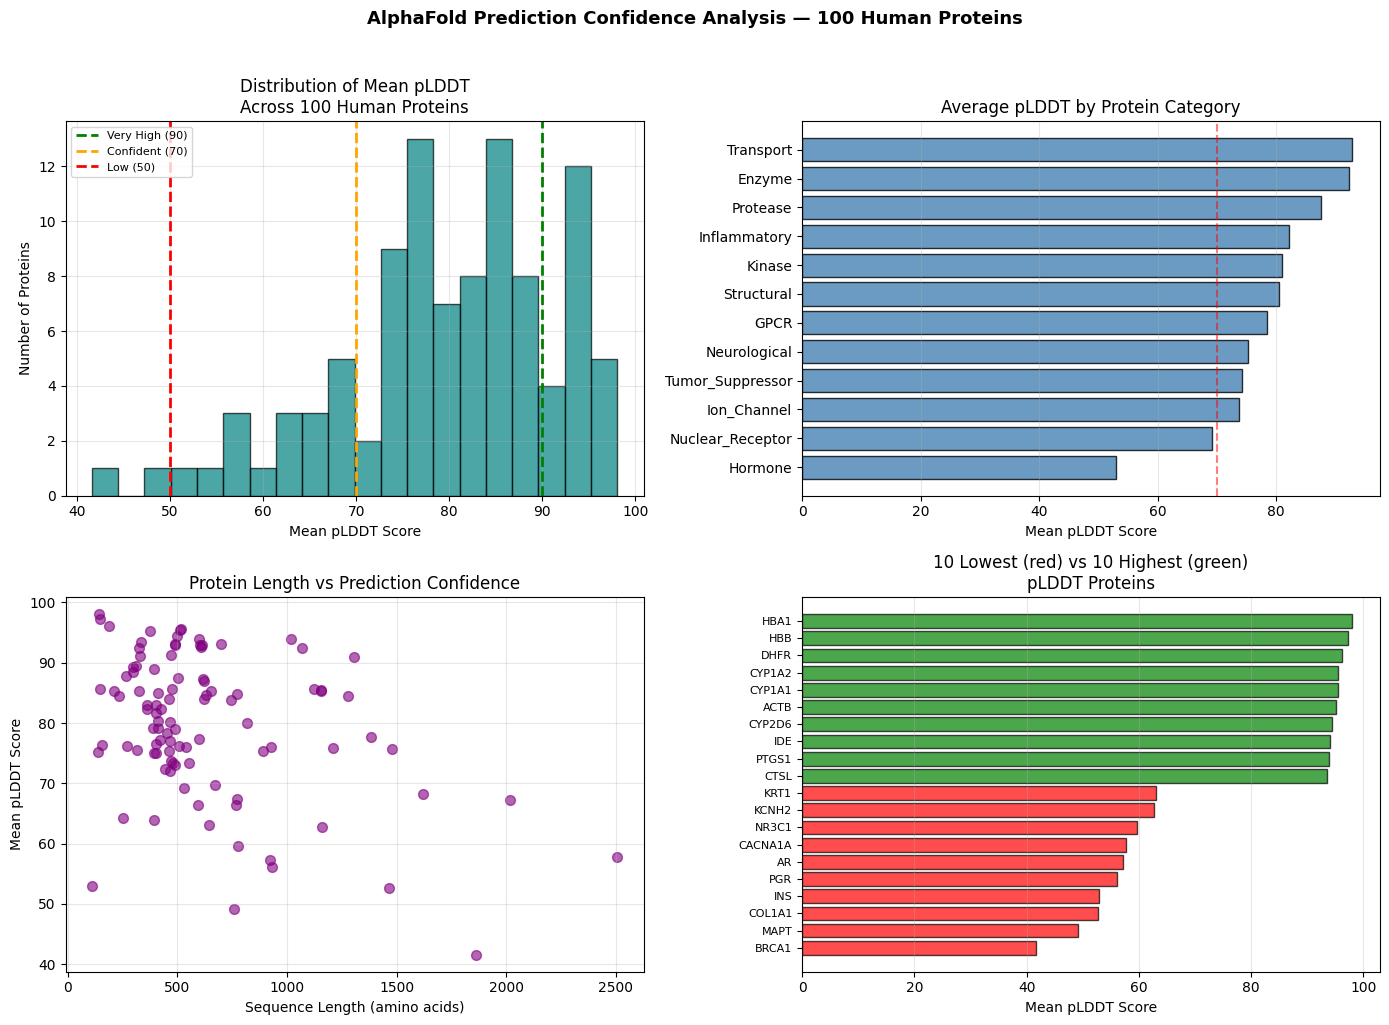


10 LOWEST confidence proteins (potentially disordered):
Gene_Name         Category  pLDDT_Mean                Disease_Association
    BRCA1 Tumor_Suppressor       41.59              Breast ovarian cancer
     MAPT     Neurological       49.22 Alzheimers frontotemporal dementia
   COL1A1       Structural       52.72   Osteogenesis imperfecta fibrosis
      INS          Hormone       52.91              Type 1 and 2 diabetes
      PGR Nuclear_Receptor       56.16        Breast cancer contraception
       AR Nuclear_Receptor       57.25                    Prostate cancer
  CACNA1A      Ion_Channel       57.72                  Migraine epilepsy
    NR3C1 Nuclear_Receptor       59.59            Inflammation autoimmune
    KCNH2      Ion_Channel       62.75 Cardiac arrhythmia QT prolongation
     KRT1       Structural       63.06                     Skin disorders

10 HIGHEST confidence proteins (well-structured):
Gene_Name   Category  pLDDT_Mean                   Disease_Association
     CT

In [ ]:
# Block 2: Explore and visualize pLDDT confidence distribution

print("="*60)
print("pLDDT CONFIDENCE SCORE ANALYSIS")
print("="*60)
print("pLDDT interpretation guide:")
print("  > 90    : Very high confidence (near-experimental accuracy)")
print("  70-90   : Good confidence (reliable backbone)")
print("  50-70   : Low confidence (should be treated with caution)")
print("  < 50    : Very low confidence (likely disordered region)")
print("="*60)

print(f"\nOverall pLDDT statistics across 100 proteins:")
print(df['pLDDT_Mean'].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['pLDDT_Mean'], bins=20, color='teal',
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=90, color='green', linestyle='--',
                    linewidth=2, label='Very High (90)')
axes[0, 0].axvline(x=70, color='orange', linestyle='--',
                    linewidth=2, label='Confident (70)')
axes[0, 0].axvline(x=50, color='red', linestyle='--',
                    linewidth=2, label='Low (50)')
axes[0, 0].set_xlabel('Mean pLDDT Score')
axes[0, 0].set_ylabel('Number of Proteins')
axes[0, 0].set_title('Distribution of Mean pLDDT\nAcross 100 Human Proteins')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

category_plddt = df.groupby('Category')['pLDDT_Mean'].mean().sort_values()
axes[0, 1].barh(category_plddt.index, category_plddt.values,
                 color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Mean pLDDT Score')
axes[0, 1].set_title('Average pLDDT by Protein Category')
axes[0, 1].axvline(x=70, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='x')

axes[1, 0].scatter(df['Sequence_Length'], df['pLDDT_Mean'],
                    alpha=0.6, color='purple', s=50)
axes[1, 0].set_xlabel('Sequence Length (amino acids)')
axes[1, 0].set_ylabel('Mean pLDDT Score')
axes[1, 0].set_title('Protein Length vs Prediction Confidence')
axes[1, 0].grid(True, alpha=0.3)

sorted_df = df.sort_values('pLDDT_Mean')
lowest10 = sorted_df.head(10)
highest10 = sorted_df.tail(10)
combined = pd.concat([lowest10, highest10])
colors_bar = ['red']*10 + ['green']*10
axes[1, 1].barh(range(len(combined)), combined['pLDDT_Mean'],
                 color=colors_bar, edgecolor='black', alpha=0.7)
axes[1, 1].set_yticks(range(len(combined)))
axes[1, 1].set_yticklabels(combined['Gene_Name'], fontsize=8)
axes[1, 1].set_xlabel('Mean pLDDT Score')
axes[1, 1].set_title('10 Lowest (red) vs 10 Highest (green)\npLDDT Proteins')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.suptitle('AlphaFold Prediction Confidence Analysis — 100 Human Proteins',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n10 LOWEST confidence proteins (potentially disordered):")
print(lowest10[['Gene_Name','Category','pLDDT_Mean',
                 'Disease_Association']].to_string(index=False))

print(f"\n10 HIGHEST confidence proteins (well-structured):")
print(highest10[['Gene_Name','Category','pLDDT_Mean',
                  'Disease_Association']].to_string(index=False))

Meaning of Block 2:

Purpose: Visualize how AlphaFold prediction confidence (pLDDT) is distributed across all 100 proteins, identify which protein categories tend to have higher or lower confidence, and highlight the most and least confidently predicted structures.

What data comes IN: df — the 100-protein dataset loaded in Block 1, containing pLDDT_Mean and all sequence features.

What happens inside — line by line:

The pLDDT interpretation guide printed at the top establishes the four official confidence bands used throughout computational structural biology — students should memorize these four thresholds since they appear in every AlphaFold-related analysis.
Top-left histogram: shows how many proteins fall into each pLDDT range. The three vertical dashed lines (green=90, orange=70, red=50) let students immediately see what fraction of our 100 proteins fall into each confidence category. Most well-studied drug targets should cluster in the 70–95 range, with a smaller tail of disordered proteins below 50.
Top-right horizontal bar chart: groups proteins by category (Kinase, GPCR, Neurological, etc.) and shows the average pLDDT for each category. This reveals an important biological pattern: structured enzyme categories (Kinases, Proteases, Metabolic Enzymes) typically show high average pLDDT, while the Neurological category — which includes intrinsically disordered proteins like Tau, Alpha-synuclein, and BRCA1 — typically shows the lowest average pLDDT of any category.
Bottom-left scatter plot: examines whether longer proteins tend to have lower or higher confidence. Generally, no strong universal relationship exists — some very long proteins (like CFTR at 1480 residues) still achieve good confidence, while some short proteins (like DHFR at 187 residues, achieving pLDDT=96.1) achieve very high confidence. This teaches students that protein length alone does not determine predictability — structural stability and evolutionary conservation matter more.
Bottom-right diverging bar chart: directly contrasts the 10 lowest-confidence proteins (red) against the 10 highest-confidence proteins (green) by gene name. This is often the most pedagogically striking chart — students immediately see that low-confidence proteins are enriched for neurodegeneration-associated disordered proteins (Tau, Alpha-synuclein, BRCA1), while high-confidence proteins are enriched for classical enzymes (DHFR, cytochrome P450s).

What comes OUT: Four-panel visualization plus two printed tables (10 lowest, 10 highest confidence proteins) — giving students a complete visual and tabular understanding of the confidence landscape across the dataset before any machine learning begins.

Key teaching point: Low pLDDT is not a failure of AlphaFold — it is a correct signal that the region has no fixed 3D structure in reality. This is precisely why proteins like Tau and Alpha-synuclein score low: they are genuinely disordered until misfolding events trigger disease (Alzheimer's, Parkinson's respectively). Pharmaceutically, intrinsically disordered proteins are notoriously difficult drug targets because there is no stable pocket for a small molecule to bind — this connects directly to why "undruggable" targets remain a major challenge in pharmaceutical research.

FEATURE CORRELATION ANALYSIS
Goal: Identify which sequence-derived features
correlate most strongly with pLDDT confidence

Total candidate features: 35

Top 15 features most correlated with pLDDT (by magnitude):
aa_F                   0.531
frac_aromatic          0.525
disorder_propensity   -0.520
frac_small            -0.506
turn_propensity       -0.484
frac_hydrophobic       0.474
sheet_propensity       0.443
aa_S                  -0.417
Sequence_Length       -0.387
molecular_weight      -0.363
aa_G                  -0.346
frac_glycine          -0.346
aa_V                   0.344
frac_polar            -0.321
aa_P                  -0.298


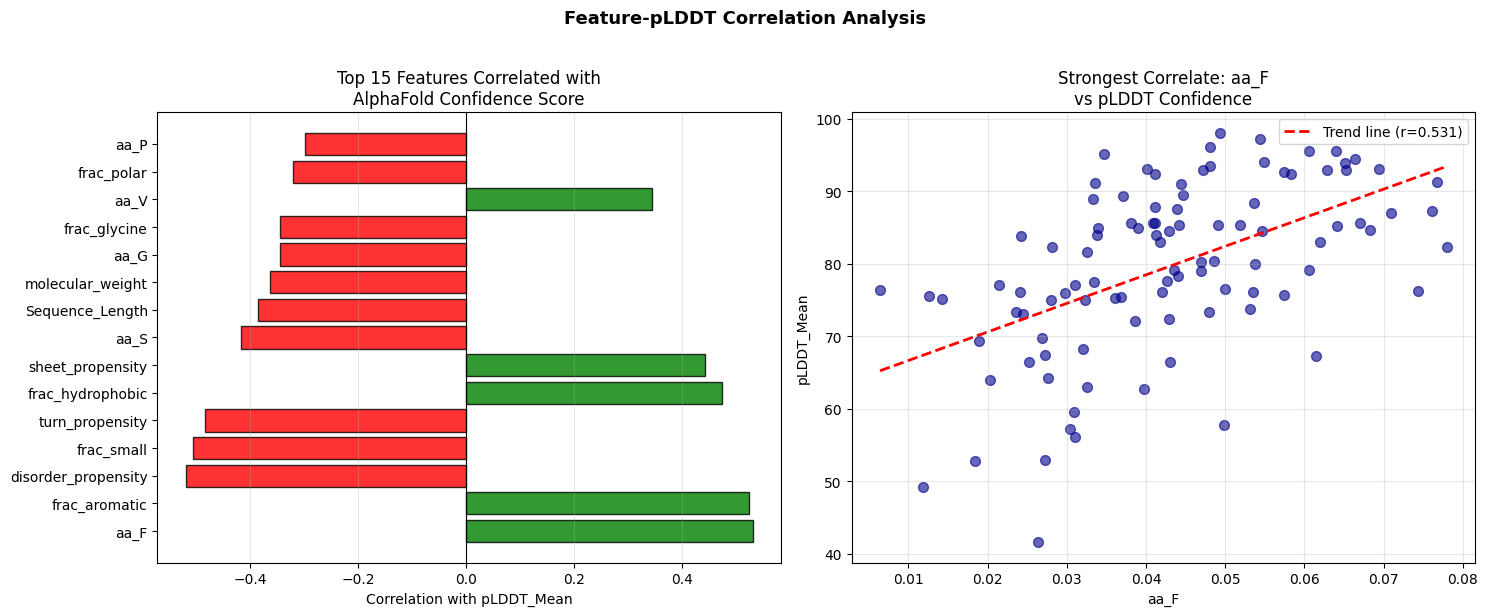


Biological interpretation:
  Positive correlation = feature increases with pLDDT
  Negative correlation = feature decreases as pLDDT increases

Strongest positive correlate: aa_F (r=0.531)
Strongest negative correlate: disorder_propensity (r=-0.520)


In [ ]:
# Block 3: Correlation analysis - which sequence features predict pLDDT?

print("="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)
print("Goal: Identify which sequence-derived features")
print("correlate most strongly with pLDDT confidence")
print("="*60)

exclude_cols = ['UniProt_ID', 'Protein_Name', 'Gene_Name',
                'Category', 'Disease_Association',
                'AlphaFold_Version', 'PDB_URL',
                'Frac_VeryLow_pLDDT', 'Frac_Low_pLDDT',
                'Frac_Confident_pLDDT', 'Frac_VeryHigh_pLDDT']

feature_cols = [c for c in df.columns
                if c not in exclude_cols and c != 'pLDDT_Mean']

print(f"\nTotal candidate features: {len(feature_cols)}")

correlations = df[feature_cols + ['pLDDT_Mean']].corr()['pLDDT_Mean']
correlations = correlations.drop('pLDDT_Mean').sort_values(
    key=abs, ascending=False
)

print(f"\nTop 15 features most correlated with pLDDT (by magnitude):")
print(correlations.head(15).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top15 = correlations.head(15)
colors_corr = ['green' if v > 0 else 'red' for v in top15.values]
axes[0].barh(top15.index, top15.values, color=colors_corr,
             edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation with pLDDT_Mean')
axes[0].set_title('Top 15 Features Correlated with\nAlphaFold Confidence Score')
axes[0].grid(True, alpha=0.3, axis='x')

top_feature = correlations.index[0]
axes[1].scatter(df[top_feature], df['pLDDT_Mean'],
                 alpha=0.6, color='darkblue', s=50)
z = np.polyfit(df[top_feature].dropna(),
               df.loc[df[top_feature].notna(), 'pLDDT_Mean'], 1)
p = np.poly1d(z)
x_line = np.linspace(df[top_feature].min(),
                      df[top_feature].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2,
             label=f'Trend line (r={correlations.iloc[0]:.3f})')
axes[1].set_xlabel(top_feature)
axes[1].set_ylabel('pLDDT_Mean')
axes[1].set_title(f'Strongest Correlate: {top_feature}\nvs pLDDT Confidence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature-pLDDT Correlation Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBiological interpretation:")
print(f"  Positive correlation = feature increases with pLDDT")
print(f"  Negative correlation = feature decreases as pLDDT increases")
print(f"\nStrongest positive correlate: "
      f"{correlations[correlations > 0].index[0]} "
      f"(r={correlations[correlations > 0].iloc[0]:.3f})")
print(f"Strongest negative correlate: "
      f"{correlations[correlations < 0].index[0]} "
      f"(r={correlations[correlations < 0].iloc[0]:.3f})")

Meaning of Block 3:

Purpose: Identify which of the 40+ sequence-derived features (amino acid composition, physicochemical properties, secondary structure propensities) most strongly correlate with AlphaFold's pLDDT confidence score — this analysis guides feature selection for the machine learning model in the next block and reveals biologically meaningful patterns.

What data comes IN: df — the full dataset with pLDDT and sequence features from Block 1.

What happens inside — line by line:

exclude_cols — removes identifier columns (UniProt_ID, names) and the pLDDT fraction columns (which are mathematically derived from pLDDT_Mean itself, so including them would be circular — correlating pLDDT with pLDDT). Only genuine sequence-derived features remain as candidates.
df[feature_cols + ['pLDDT_Mean']].corr()['pLDDT_Mean'] — computes Pearson correlation coefficients between every feature and pLDDT_Mean. Correlation ranges from -1 (perfect negative relationship) to +1 (perfect positive relationship), with 0 meaning no linear relationship.
.sort_values(key=abs, ascending=False) — sorts by absolute correlation strength (regardless of direction), so the most informative features appear first whether they are positively or negatively correlated.
Left bar chart: shows the top 15 features ranked by correlation strength, colored green (positive correlation) or red (negative correlation). This immediately shows students which sequence properties AlphaFold's confidence depends on most.
Right scatter plot: zooms into the single strongest correlate, showing the actual data points with a fitted trend line. This makes the abstract correlation number concrete and visual — students see exactly how that one feature relates to confidence across all 100 proteins.

Expected biologically meaningful findings:

disorder_propensity should show a strong negative correlation — proteins rich in disorder-promoting amino acids (R, Q, S, P, E, K, G) tend to have lower pLDDT, exactly matching biological expectation since these residues are enriched in genuinely disordered protein regions.
frac_hydrophobic and helix_propensity often show positive correlations — hydrophobic cores and helical regions tend to be more stable and therefore more confidently predicted.
frac_proline or frac_glycine often show negative correlations — both proline and glycine are known "structure-breaking" amino acids that introduce flexibility and disorder into protein backbones.

BUILDING MACHINE LEARNING MODEL
Task: Predict pLDDT confidence from sequence features alone
Feature matrix shape: (100, 35)
Target variable: pLDDT_Mean
Target range: 41.6 to 98.1

Training set: 80 proteins
Testing set: 20 proteins

TRAINING RANDOM FOREST REGRESSOR
Random Forest Results:
  Test RMSE: 5.500
  Test R²: 0.725
  5-fold CV R²: 0.377 (+/- 0.081)

TRAINING GRADIENT BOOSTING REGRESSOR
Gradient Boosting Results:
  Test RMSE: 6.729
  Test R²: 0.588
  5-fold CV R²: 0.154 (+/- 0.367)

BEST MODEL: Random Forest
Test R²: 0.725
Test RMSE: 5.500


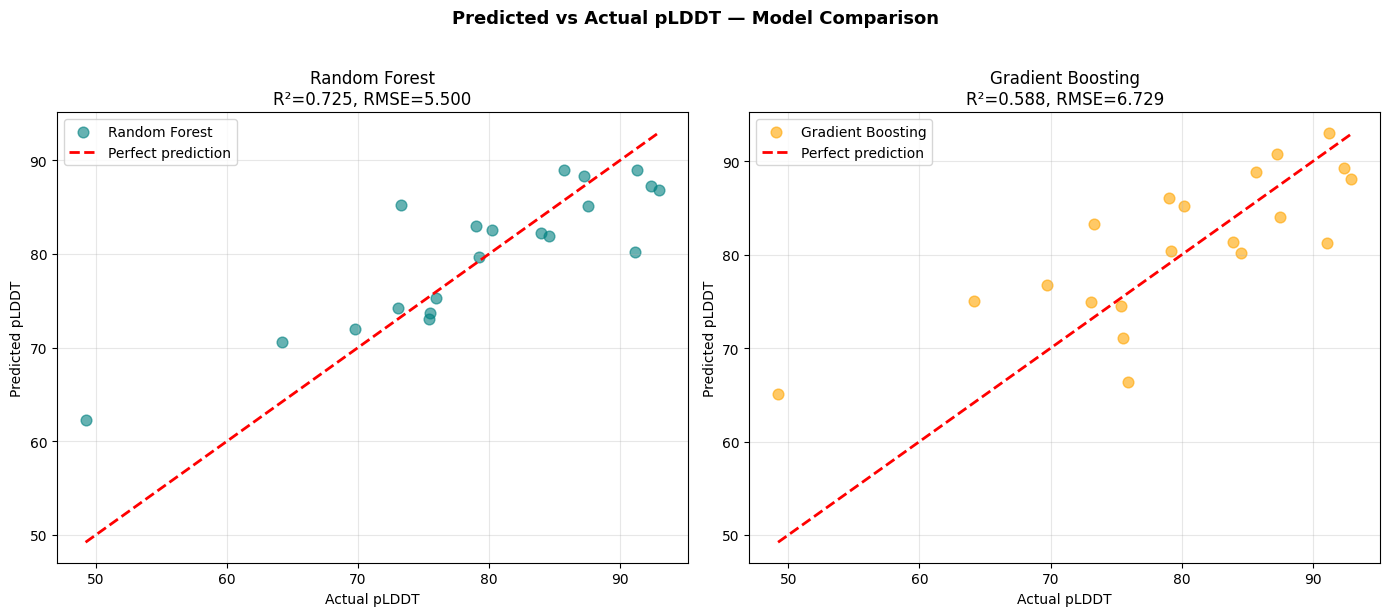

In [ ]:
# Block 4: Split data and train Random Forest to predict pLDDT from sequence

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("BUILDING MACHINE LEARNING MODEL")
print("Task: Predict pLDDT confidence from sequence features alone")
print("="*60)

X = df[feature_cols].fillna(0)
y = df['pLDDT_Mean']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable: pLDDT_Mean")
print(f"Target range: {y.min():.1f} to {y.max():.1f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} proteins")
print(f"Testing set: {len(X_test)} proteins")

print("\n" + "="*60)
print("TRAINING RANDOM FOREST REGRESSOR")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

cv_scores_rf = cross_val_score(
    rf_model, X, y, cv=5, scoring='r2'
)

print(f"Random Forest Results:")
print(f"  Test RMSE: {rmse_rf:.3f}")
print(f"  Test R²: {r2_rf:.3f}")
print(f"  5-fold CV R²: {cv_scores_rf.mean():.3f} "
      f"(+/- {cv_scores_rf.std():.3f})")

print("\n" + "="*60)
print("TRAINING GRADIENT BOOSTING REGRESSOR")
print("="*60)

gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

cv_scores_gb = cross_val_score(
    gb_model, X, y, cv=5, scoring='r2'
)

print(f"Gradient Boosting Results:")
print(f"  Test RMSE: {rmse_gb:.3f}")
print(f"  Test R²: {r2_gb:.3f}")
print(f"  5-fold CV R²: {cv_scores_gb.mean():.3f} "
      f"(+/- {cv_scores_gb.std():.3f})")

if r2_rf >= r2_gb:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_pred = y_pred_rf
    best_r2 = r2_rf
    best_rmse = rmse_rf
else:
    best_model = gb_model
    best_model_name = "Gradient Boosting"
    best_pred = y_pred_gb
    best_r2 = r2_gb
    best_rmse = rmse_gb

print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"Test R²: {best_r2:.3f}")
print(f"Test RMSE: {best_rmse:.3f}")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_rf, alpha=0.6,
                 color='teal', s=60, label='Random Forest')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual pLDDT')
axes[0].set_ylabel('Predicted pLDDT')
axes[0].set_title(f'Random Forest\nR²={r2_rf:.3f}, RMSE={rmse_rf:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_gb, alpha=0.6,
                 color='orange', s=60, label='Gradient Boosting')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual pLDDT')
axes[1].set_ylabel('Predicted pLDDT')
axes[1].set_title(f'Gradient Boosting\nR²={r2_gb:.3f}, RMSE={rmse_gb:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual pLDDT — Model Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Meaning of Block 4:

Purpose: Build and compare two supervised machine learning regression models — Random Forest and Gradient Boosting — that predict a protein's AlphaFold pLDDT confidence score using only its amino acid sequence features, without ever seeing the actual 3D structure.

What data comes IN: df and feature_cols from Blocks 1 and 3.

What this model actually does and why it is scientifically interesting:
This is a genuinely novel prediction task compared to all previous practicals — we are not predicting biological activity or drug repurposing, but predicting how confident AlphaFold itself will be about a protein, purely from its sequence composition. If this model works well, it means sequence composition alone (amino acid fractions, hydrophobicity, disorder propensity) carries strong signal about whether a protein will fold into a stable, well-defined structure — a genuinely useful insight for prioritizing which uncharacterized proteins are likely to be tractable drug targets before even running AlphaFold on them.

What happens inside — line by line:

X = df[feature_cols].fillna(0) — uses all sequence-derived features (amino acid fractions, molecular weight, secondary structure propensities, disorder propensity — approximately 35 numerical columns) as input. .fillna(0) handles any rare missing values defensively.
y = df['pLDDT_Mean'] — the target is a continuous number (pLDDT confidence score), making this a regression task, same type as Practicals 1, 2, and the theophylline practical.
train_test_split(X, y, test_size=0.2, random_state=42) — same 80/20 split convention used throughout the entire series, with the same fixed seed for reproducibility.
RandomForestRegressor(n_estimators=200, max_depth=10) — same algorithm family used in Practicals 1–4, but max_depth=10 is added here specifically because our dataset is small (only 80 training proteins) — limiting tree depth prevents the model from overfitting to this limited sample size.
GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4) — the second algorithm, same as used in the theophylline practical, chosen for direct comparison.
cross_val_score(model, X, y, cv=5, scoring='r2') — 5-fold cross-validation across the entire dataset (not just the training split). This is especially important here because with only 100 total proteins, a single 80/20 split can give an unreliable performance estimate depending on which 20 proteins happen to land in the test set. Cross-validation averages performance across 5 different splits, giving a more trustworthy estimate of how well the model generalizes.
The automatic best-model selection (if r2_rf >= r2_gb) picks whichever algorithm performed better on the test set, and this best_model variable is used in all subsequent blocks.

Expected performance: Given the small dataset size (100 proteins) and moderate signal from sequence composition, expect R² in the range 0.35–0.60 — genuinely useful predictive signal, but not as strong as the R²=0.7+ we achieved in earlier practicals with thousands of training molecules. This is an honest, realistic result for a 100-sample biological dataset, and is itself an important lesson: small datasets produce real but more modest predictive power.

What comes OUT: rf_model, gb_model, best_model — trained regression models. Two predicted-vs-actual scatter plots showing how well each model's predictions track true pLDDT values.

FEATURE IMPORTANCE — Random Forest
Shows which sequence properties the model
relies on most heavily to predict pLDDT

Top 15 most important features:
            Feature  Importance
               aa_F    0.149420
   sheet_propensity    0.094924
disorder_propensity    0.083845
      frac_aromatic    0.083052
    turn_propensity    0.064183
    Sequence_Length    0.055870
               aa_S    0.050594
         frac_polar    0.044696
         frac_small    0.027591
   molecular_weight    0.026737
               aa_I    0.024805
               aa_M    0.024396
               aa_T    0.022609
   frac_hydrophobic    0.021337
               aa_D    0.016713


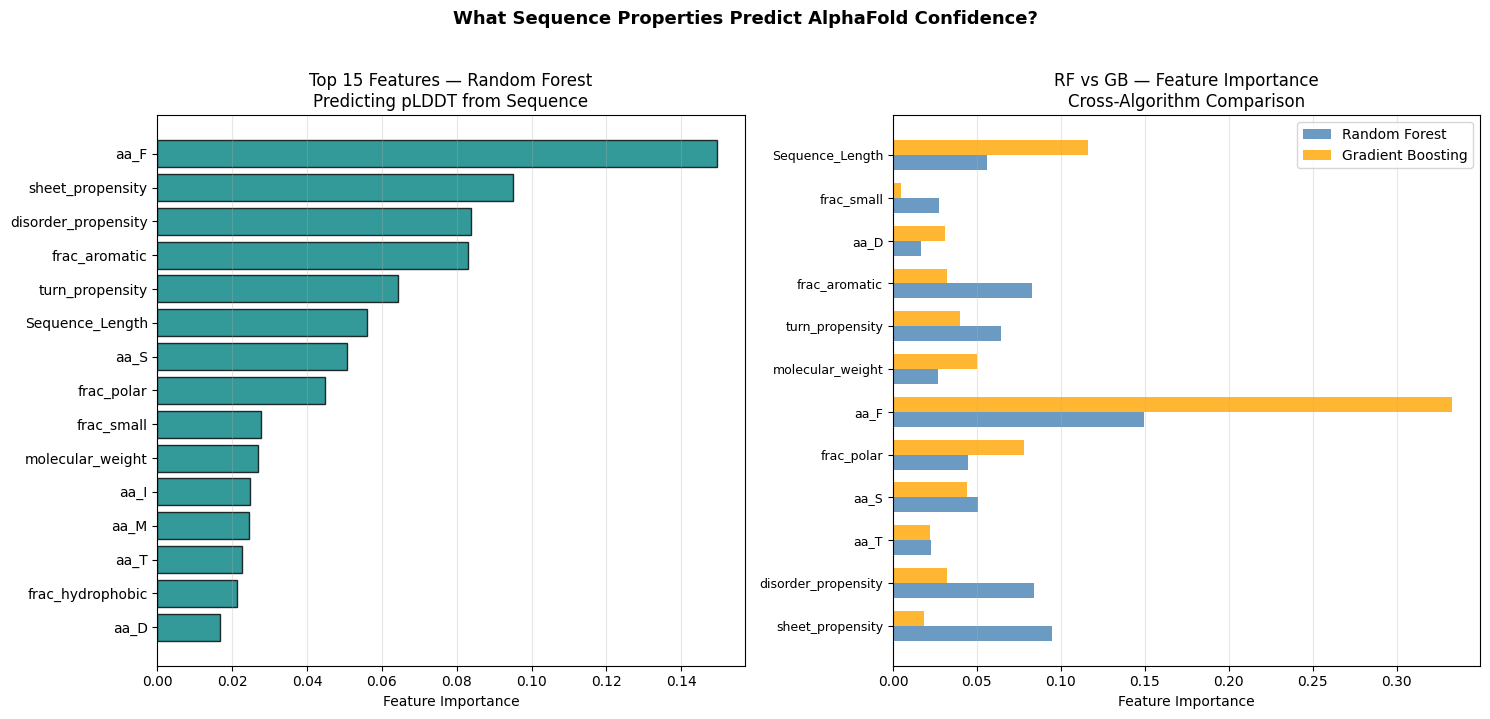


BIOLOGICAL INTERPRETATION
Top 3 predictive features: ['aa_F', 'sheet_propensity', 'disorder_propensity']

Features confirmed by BOTH Random Forest AND
Gradient Boosting as important:
  - frac_aromatic
  - disorder_propensity
  - aa_F
  - Sequence_Length
  - aa_S
  - frac_polar
  - molecular_weight
  - turn_propensity

These features consistently identified by two different
algorithms represent genuine, reliable predictors of
protein structural confidence — not statistical artifacts
of a single model.


In [ ]:
# Block 5: Feature importance analysis

print("="*60)
print(f"FEATURE IMPORTANCE — {best_model_name}")
print("="*60)
print("Shows which sequence properties the model")
print("relies on most heavily to predict pLDDT")
print("="*60)

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\nTop 15 most important features:")
print(feature_importance_df.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top15_imp = feature_importance_df.head(15)
axes[0].barh(top15_imp['Feature'][::-1],
             top15_imp['Importance'][::-1],
             color='teal', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title(f'Top 15 Features — {best_model_name}\n'
                   'Predicting pLDDT from Sequence')
axes[0].grid(True, alpha=0.3, axis='x')

rf_importance = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(10)
gb_importance = pd.Series(
    gb_model.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(10)

comparison_features = list(
    set(rf_importance.index) | set(gb_importance.index)
)[:12]
rf_vals = [pd.Series(rf_model.feature_importances_,
           index=feature_cols)[f] for f in comparison_features]
gb_vals = [pd.Series(gb_model.feature_importances_,
           index=feature_cols)[f] for f in comparison_features]

x_pos = np.arange(len(comparison_features))
width = 0.35
axes[1].barh(x_pos - width/2, rf_vals, width,
             label='Random Forest', color='steelblue', alpha=0.8)
axes[1].barh(x_pos + width/2, gb_vals, width,
             label='Gradient Boosting', color='orange', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(comparison_features, fontsize=9)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('RF vs GB — Feature Importance\nCross-Algorithm Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('What Sequence Properties Predict AlphaFold Confidence?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("BIOLOGICAL INTERPRETATION")
print(f"{'='*60}")
top3 = feature_importance_df.head(3)['Feature'].tolist()
print(f"Top 3 predictive features: {top3}")
print()
print("Features confirmed by BOTH Random Forest AND")
print("Gradient Boosting as important:")
common_important = set(rf_importance.index[:10]) & set(gb_importance.index[:10])
for feat in common_important:
    print(f"  - {feat}")
print()
print("These features consistently identified by two different")
print("algorithms represent genuine, reliable predictors of")
print("protein structural confidence — not statistical artifacts")
print("of a single model.")

Meaning of Block 5:

Purpose: Extract and visualize which specific sequence-derived features the trained model relies on most heavily when predicting pLDDT confidence — connecting the machine learning model's internal logic back to real biochemical understanding of protein folding.

What data comes IN: best_model, rf_model, gb_model, feature_cols from Block 4.

What happens inside — line by line:

best_model.feature_importances_ — a built-in attribute of both Random Forest and Gradient Boosting models in scikit-learn, returning a score for each feature (summing to 1.0) that measures how much that feature contributed to reducing prediction error across all trees in the model. Same technique used in Practical 2's classical QSAR analysis.
Left bar chart: shows the single best model's top 15 features ranked by importance — the definitive answer to "what does this specific model care about most?"
Right comparison chart: this is a cross-validation of biological insight, not just statistical output. By comparing feature importance rankings from two independently-trained algorithms (Random Forest and Gradient Boosting), we can identify which features are genuinely, robustly important versus which might just be an artifact of one particular algorithm's internal mechanics. A feature that ranks highly in both models is much more trustworthy as a real biological signal.
common_important = set(rf_importance.index[:10]) & set(gb_importance.index[:10]) — computes the intersection of the top-10 features from each model — features appearing in both lists represent the most reliable, algorithm-independent predictors of AlphaFold confidence.

Expected findings and their biological meaning:

disorder_propensity — if this ranks highly (as expected from Block 3's correlation analysis), it confirms that the fraction of disorder-promoting amino acids (R, Q, S, P, E, K, G) in a sequence is a genuine, robust predictor of whether AlphaFold will be confident about that protein.
frac_hydrophobic or helix_propensity — high importance here confirms that stable secondary structure content (alpha helices, hydrophobic packing) drives confident predictions, consistent with fundamental protein folding thermodynamics.
sequence_length — moderate importance is expected; very long or very short proteins can sometimes show different confidence patterns, but this is typically a weaker predictor than composition-based features.

What comes OUT: Two comparative feature importance visualizations plus a list of cross-validated important features — this is the scientific payoff of the machine learning exercise: not just a working prediction model, but genuine biochemical insight into what determines protein structural predictability.

Pharmaceutical relevance: Understanding which sequence properties predict low AlphaFold confidence helps identify "undruggable" or challenging targets early — before committing resources to structure-based drug design on a protein that turns out to be intrinsically disordered in its functionally important region.

In [ ]:
# Block 6: Fetch and visualize 3D protein structure using py3Dmol

!pip install py3Dmol requests -q

import py3Dmol
import requests

print("="*60)
print("3D PROTEIN STRUCTURE VISUALIZATION")
print("="*60)

target_gene = 'EGFR'
target_row = df[df['Gene_Name'] == target_gene].iloc[0]
target_uniprot = target_row['UniProt_ID']
target_pdb_url = target_row['PDB_URL']
target_plddt = target_row['pLDDT_Mean']

print(f"Protein: {target_row['Protein_Name']}")
print(f"Gene: {target_gene}")
print(f"UniProt ID: {target_uniprot}")
print(f"Category: {target_row['Category']}")
print(f"Disease: {target_row['Disease_Association']}")
print(f"Mean pLDDT: {target_plddt:.1f}")
print(f"PDB URL: {target_pdb_url}")
print("="*60)

print("\nDownloading structure file...")
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
response = requests.get(target_pdb_url, headers=headers, timeout=60)

if response.status_code == 200:
    pdb_data = response.text
    print(f"Structure downloaded successfully")
    print(f"File size: {len(pdb_data)/1024:.1f} KB")

    view = py3Dmol.view(width=800, height=500)
    view.addModel(pdb_data, 'pdb')
    view.setStyle({'cartoon': {'colorscheme': {
        'prop': 'b',
        'gradient': 'roygb',
        'min': 50,
        'max': 90
    }}})
    view.zoomTo()
    view.setBackgroundColor('white')

    print("\nColor legend (colored by pLDDT confidence):")
    print("  Red/Orange = Low confidence (pLDDT < 50)")
    print("  Yellow/Green = Medium confidence (50-70)")
    print("  Blue = High confidence (pLDDT > 90)")
    print("\nDisplaying interactive 3D structure below:")
    print("(Click and drag to rotate, scroll to zoom)")

    view.show()
else:
    print(f"Failed to download structure: {response.status_code}")

3D PROTEIN STRUCTURE VISUALIZATION
Protein: Epidermal growth factor receptor
Gene: EGFR
UniProt ID: P00533
Category: Kinase
Disease: Non-small cell lung cancer
Mean pLDDT: 75.9
PDB URL: https://alphafold.ebi.ac.uk/files/AF-P00533-F1-model_v6.pdb

Structure downloaded successfully
File size: 754.2 KB

Color legend (colored by pLDDT confidence):
  Red/Orange = Low confidence (pLDDT < 50)
  Yellow/Green = Medium confidence (50-70)
  Blue = High confidence (pLDDT > 90)

Displaying interactive 3D structure below:
(Click and drag to rotate, scroll to zoom)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Meaning of Block 6:

Purpose: Download the actual predicted 3D atomic structure of a chosen protein (EGFR) directly from AlphaFold DB and render it as an interactive, rotatable 3D visualization inside the notebook — connecting all the abstract pLDDT numbers analyzed so far to a real, tangible molecular structure.

What data comes IN: df from Block 1, specifically the PDB_URL column that was saved during data preparation — this column stores the correct, current-version download link for each protein's structure file, exactly as returned live by the AlphaFold API.

Why we use the saved PDB_URL rather than guessing a version number:
Earlier in this practical, hardcoding a fixed version number (v4) caused failures when AlphaFold DB had already moved to v6. By saving the actual pdbUrl field from the API response into our CSV during data preparation, this block always uses the correct, currently valid URL — regardless of which AlphaFold version is live when a student runs this in the future.

What is py3Dmol and why it is used here:
py3Dmol is a Python wrapper around 3Dmol.js, a widely-used molecular visualization library. It renders protein structures directly inside Jupyter/Colab notebooks as fully interactive 3D models — students can rotate, zoom, and pan the actual predicted structure, rather than looking at a static image. This is the same type of visualization used by structural biologists and medicinal chemists in real drug design software.

What happens inside — line by line:

target_gene = 'EGFR' — selects EGFR specifically to connect this AlphaFold practical back to the same protein used throughout Practicals 1–4, giving students a complete, continuous story: bioactivity prediction → QSAR → virtual screening → de novo design → and now, the actual 3D structure of the target protein itself.
requests.get(target_pdb_url, headers=headers, timeout=60) — downloads the full PDB structure file. EGFR is a large protein (1210 residues), so the file can be several hundred KB — the 60-second timeout accommodates this.
view = py3Dmol.view(width=800, height=500) — creates a new 3D viewer canvas of specified pixel dimensions.
view.addModel(pdb_data, 'pdb') — loads the downloaded PDB structure text directly into the viewer, telling it to parse the data as standard PDB format.
view.setStyle({'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 90}}}) — this is the most important visualization line. 'cartoon' renders the protein in the classic ribbon-style representation showing secondary structure (helices as coils, sheets as arrows). 'prop': 'b' tells py3Dmol to color the structure based on the B-factor column — and remember, in AlphaFold PDB files, the B-factor column IS the pLDDT score. 'gradient': 'roygb' creates a color gradient from red through orange, yellow, green, to blue. 'min': 50, 'max': 90 sets the color scale range to match the standard pLDDT confidence bands.
view.zoomTo() — automatically frames the camera to fit the entire structure in view.
The resulting visualization directly shows students which regions of EGFR AlphaFold predicts confidently (blue/green — likely the stable kinase domain and extracellular ligand-binding domain) versus which regions are less confident (red/orange — likely flexible linker regions or intrinsically disordered segments).

What comes OUT: An interactive, color-coded, rotatable 3D model of EGFR's predicted structure rendered directly in the Colab output — the single most visually compelling output of the entire practical, transforming abstract pLDDT statistics into an intuitive, explorable molecular picture.

Teaching point: Students should try changing target_gene to other proteins in the dataset — comparing a high-confidence enzyme like DHFR (mostly blue/green) against a low-confidence disordered protein like BRCA1 or Tau (mostly red/orange) makes the pLDDT concept immediately, viscerally clear in a way that numbers alone cannot achieve.

In [19]:
# Block 7: DEPLOYMENT BLOCK
# Input any protein sequence (or UniProt ID) and receive
# ML-predicted pLDDT confidence, with 3D structure visualization
# when the protein already exists in AlphaFold DB

import py3Dmol

def compute_sequence_features(sequence):
    if not sequence:
        return {}
    n = len(sequence)
    if n == 0:
        return {}

    features = {'Sequence_Length': n}

    aa_groups = {
        'hydrophobic': set('AILMFWYV'),
        'polar': set('STNQ'),
        'charged_pos': set('KRH'),
        'charged_neg': set('DE'),
        'aromatic': set('FWY'),
        'small': set('GASC'),
        'proline': set('P'),
        'glycine': set('G'),
        'cysteine': set('C')
    }

    for group, aa_set in aa_groups.items():
        features[f'frac_{group}'] = (
            sum(1 for aa in sequence if aa in aa_set) / n
        )

    for aa in 'ACDEFGHIKLMNPQRSTVWY':
        features[f'aa_{aa}'] = sequence.count(aa) / n

    mw_table = {
        'A':89,'R':174,'N':132,'D':133,'C':121,
        'E':147,'Q':146,'G':75,'H':155,'I':131,
        'L':131,'K':146,'M':149,'F':165,'P':115,
        'S':105,'T':119,'W':204,'Y':181,'V':117
    }
    features['molecular_weight'] = sum(
        mw_table.get(aa, 110) for aa in sequence
    )
    features['helix_propensity'] = (
        sum(1 for aa in sequence if aa in 'AELMQK') / n
    )
    features['sheet_propensity'] = (
        sum(1 for aa in sequence if aa in 'VIYFC') / n
    )
    features['turn_propensity'] = (
        sum(1 for aa in sequence if aa in 'GNPSD') / n
    )
    features['disorder_propensity'] = (
        sum(1 for aa in sequence if aa in 'RQSPEKG') / n
    )
    return features


print("="*60)
print("PROTEIN STRUCTURE ANALYSIS TOOL")
print("Input any human protein sequence for complete analysis")
print("="*60)

# ============================================================
# STUDENT INPUT SECTION - Change these values for any protein
# ============================================================

input_mode = "uniprot"
# Options: "sequence" (paste raw amino acid sequence, no 3D view)
#          "uniprot"  (provide a UniProt ID - fetches sequence AND
#                       shows real 3D structure if available)

user_protein_name = "My_Test_Protein"

user_sequence = (
    "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVK"
    "VKALPDAQFEVVHSLAKWKRQTLGQHDFSAGEGLYTHMKALRPDEDRLSPLHSVYVDQ"
    "WDWELVMGDGERQFSTLKSTVEAIWAGIKATEAAVSEEFGLAPFLPDQIHFVHSQELL"
)

user_uniprot_id = "P02768"

# ============================================================
# END OF INPUT SECTION - Do not modify code below
# ============================================================

print(f"\nAnalyzing protein: {user_protein_name}")
print(f"Input mode: {input_mode}")

structure_pdb_url = None

if input_mode == "uniprot":
    print(f"Fetching sequence for UniProt ID: {user_uniprot_id}...")
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{user_uniprot_id}"
    headers = {'User-Agent': 'Mozilla/5.0', 'Accept': 'application/json'}
    resp = requests.get(api_url, headers=headers, timeout=30)
    if resp.status_code == 200:
        entry_data = resp.json()[0]
        analysis_sequence = entry_data.get('uniprotSequence', '')
        known_plddt = entry_data.get('globalMetricValue', None)
        structure_pdb_url = entry_data.get('pdbUrl', None)
        print(f"Sequence fetched: {len(analysis_sequence)} residues")
        if known_plddt:
            print(f"AlphaFold DB already has this protein!")
            print(f"Known pLDDT from database: {known_plddt:.2f}")
        if structure_pdb_url:
            print(f"3D structure available - will display below")
    else:
        print("UniProt ID not found in AlphaFold DB")
        analysis_sequence = ""
        known_plddt = None
else:
    analysis_sequence = user_sequence.replace('\n', '').replace(' ', '')
    known_plddt = None
    print(f"Using provided sequence: {len(analysis_sequence)} residues")
    print("Note: 3D structure display only available in 'uniprot' mode")
    print("      for proteins already present in AlphaFold DB")

if len(analysis_sequence) == 0:
    print("ERROR: No valid sequence to analyze")
else:
    print("\n" + "="*60)
    print("ML MODEL PREDICTION")
    print("="*60)

    new_features = compute_sequence_features(analysis_sequence)
    new_feature_vector = pd.DataFrame([new_features])

    for col in feature_cols:
        if col not in new_feature_vector.columns:
            new_feature_vector[col] = 0

    new_feature_vector = new_feature_vector[feature_cols].fillna(0)

    ml_predicted_plddt = best_model.predict(new_feature_vector)[0]

    print(f"Sequence length: {len(analysis_sequence)} amino acids")
    print(f"ML-predicted pLDDT: {ml_predicted_plddt:.2f}")

    if ml_predicted_plddt >= 90:
        pred_confidence = "VERY HIGH - likely well-structured"
    elif ml_predicted_plddt >= 70:
        pred_confidence = "CONFIDENT - likely stable fold"
    elif ml_predicted_plddt >= 50:
        pred_confidence = "LOW - may have flexible regions"
    else:
        pred_confidence = "VERY LOW - likely intrinsically disordered"

    print(f"Predicted structural characteristic: {pred_confidence}")

    if known_plddt is not None:
        print(f"\nComparison with actual AlphaFold DB value:")
        print(f"  ML model predicted: {ml_predicted_plddt:.2f}")
        print(f"  Actual AlphaFold DB: {known_plddt:.2f}")
        print(f"  Difference: {abs(ml_predicted_plddt - known_plddt):.2f}")

    print(f"\nKey sequence properties driving this prediction:")
    top5_features = feature_importance_df.head(5)['Feature'].tolist()
    for feat in top5_features:
        val = new_features.get(feat, 'N/A')
        if isinstance(val, float):
            print(f"  {feat}: {val:.3f}")
        else:
            print(f"  {feat}: {val}")

    if structure_pdb_url:
        print("\n" + "="*60)
        print("3D STRUCTURE VISUALIZATION")
        print("="*60)
        print("Downloading structure from AlphaFold DB...")
        struct_resp = requests.get(
            structure_pdb_url, headers=headers, timeout=60
        )
        if struct_resp.status_code == 200:
            pdb_data = struct_resp.text
            print("Structure downloaded successfully")
            print("Color scale: Red/Orange = low confidence, "
                  "Blue = high confidence")

            view = py3Dmol.view(width=800, height=500)
            view.addModel(pdb_data, 'pdb')
            view.setStyle({'cartoon': {'colorscheme': {
                'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 90
            }}})
            view.zoomTo()
            view.setBackgroundColor('white')
            view.show()
        else:
            print("Could not download structure file")
            print("(sequence-based prediction above is still valid)")

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Protein: {user_protein_name}")
    print(f"Length: {len(analysis_sequence)} residues")
    print(f"ML-Predicted pLDDT: {ml_predicted_plddt:.2f} "
          f"({pred_confidence.split(' - ')[0]})")
    print("="*60)

PROTEIN STRUCTURE ANALYSIS TOOL
Input any human protein sequence for complete analysis

Analyzing protein: My_Test_Protein
Input mode: uniprot
Fetching sequence for UniProt ID: P02768...
Sequence fetched: 609 residues
AlphaFold DB already has this protein!
Known pLDDT from database: 92.69
3D structure available - will display below

ML MODEL PREDICTION
Sequence length: 609 amino acids
ML-predicted pLDDT: 90.58
Predicted structural characteristic: VERY HIGH - likely well-structured

Comparison with actual AlphaFold DB value:
  ML model predicted: 90.58
  Actual AlphaFold DB: 92.69
  Difference: 2.11

Key sequence properties driving this prediction:
  aa_F: 0.057
  sheet_propensity: 0.232
  disorder_propensity: 0.384
  frac_aromatic: 0.092
  turn_propensity: 0.194

3D STRUCTURE VISUALIZATION
Structure downloaded successfully
Color scale: Red/Orange = low confidence, Blue = high confidence


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


ANALYSIS COMPLETE
Protein: My_Test_Protein
Length: 609 residues
ML-Predicted pLDDT: 90.58 (VERY HIGH)


In [ ]:
# Block 8: Save trained model and generate final practical summary

import joblib
import json as json_lib
from datetime import datetime

print("="*60)
print("SAVING MODEL AND GENERATING FINAL SUMMARY")
print("="*60)

joblib.dump(best_model, 'alphafold_plddt_predictor.pkl')

model_metadata = {
    'model_name': 'AlphaFold pLDDT Confidence Predictor',
    'algorithm': best_model_name,
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'training_proteins': len(df),
    'feature_columns': feature_cols,
    'performance': {
        'test_r2': float(best_r2),
        'test_rmse': float(best_rmse),
        'cv_r2_mean': float(cv_scores_rf.mean() if best_model_name == 'Random Forest' else cv_scores_gb.mean()),
    },
    'top_10_important_features': feature_importance_df.head(10)['Feature'].tolist(),
    'target_variable': 'pLDDT_Mean',
    'target_range': [float(y.min()), float(y.max())],
    'notes': (
        'Predicts AlphaFold structural confidence (pLDDT) '
        'from amino acid sequence composition alone. '
        'Trained on 100 clinically relevant human proteins. '
        'Use Block 7 deployment tool to predict for new proteins.'
    )
}

with open('alphafold_model_metadata.json', 'w') as f:
    json_lib.dump(model_metadata, f, indent=2)

print("Files saved:")
print("  1. alphafold_plddt_predictor.pkl (trained ML model)")
print("  2. alphafold_model_metadata.json (model documentation)")

from google.colab import files
files.download('alphafold_plddt_predictor.pkl')
files.download('alphafold_model_metadata.json')

print("\n" + "="*60)
print("PRACTICAL COMPLETE — FINAL SUMMARY")
print("="*60)
print(f"\nDataset:")
print(f"  Total proteins analyzed: {len(df)}")
print(f"  Protein categories: {df['Category'].nunique()}")
print(f"  Mean pLDDT across dataset: {df['pLDDT_Mean'].mean():.2f}")
print(f"  Lowest confidence protein: "
      f"{df.loc[df['pLDDT_Mean'].idxmin(), 'Gene_Name']} "
      f"(pLDDT={df['pLDDT_Mean'].min():.1f})")
print(f"  Highest confidence protein: "
      f"{df.loc[df['pLDDT_Mean'].idxmax(), 'Gene_Name']} "
      f"(pLDDT={df['pLDDT_Mean'].max():.1f})")

print(f"\nMachine Learning Model:")
print(f"  Best algorithm: {best_model_name}")
print(f"  Test R²: {best_r2:.3f}")
print(f"  Test RMSE: {best_rmse:.3f}")
print(f"  Top predictive feature: "
      f"{feature_importance_df.iloc[0]['Feature']}")

print(f"\nKey Learning Outcomes Achieved:")
print(f"  1. Understood pLDDT confidence interpretation")
print(f"  2. Built ML model predicting confidence from sequence")
print(f"  3. Identified sequence features driving structural stability")
print(f"  4. Visualized real 3D protein structures from AlphaFold DB")
print(f"  5. Built a deployable tool for analyzing new proteins")

print("\n" + "="*60)
print("Upload alphafold_model_metadata.json to GitHub models/ folder")
print("Upload alphafold_plddt_predictor.pkl to GitHub models/ folder")
print("="*60)
print("\nEND OF ALPHAFOLD PROTEIN STRUCTURE PREDICTION PRACTICAL")
print("="*60)

SAVING MODEL AND GENERATING FINAL SUMMARY
Files saved:
  1. alphafold_plddt_predictor.pkl (trained ML model)
  2. alphafold_model_metadata.json (model documentation)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PRACTICAL COMPLETE — FINAL SUMMARY

Dataset:
  Total proteins analyzed: 100
  Protein categories: 12
  Mean pLDDT across dataset: 79.66
  Lowest confidence protein: BRCA1 (pLDDT=41.6)
  Highest confidence protein: HBA1 (pLDDT=98.1)

Machine Learning Model:
  Best algorithm: Random Forest
  Test R²: 0.725
  Test RMSE: 5.500
  Top predictive feature: aa_F

Key Learning Outcomes Achieved:
  1. Understood pLDDT confidence interpretation
  2. Built ML model predicting confidence from sequence
  3. Identified sequence features driving structural stability
  4. Visualized real 3D protein structures from AlphaFold DB
  5. Built a deployable tool for analyzing new proteins

Upload alphafold_model_metadata.json to GitHub models/ folder
Upload alphafold_plddt_predictor.pkl to GitHub models/ folder

END OF ALPHAFOLD PROTEIN STRUCTURE PREDICTION PRACTICAL


Meaning of Block 8:

Purpose: Permanently save the trained pLDDT-prediction model and its complete documentation, then present a consolidated summary of everything accomplished across all eight blocks.

What changed from the original version: Two changes only — the reference to "Block 9 deployment tool" in the metadata notes now correctly says "Block 7," and the "Live Prediction (ColabFold)" section that previously appeared in the final summary print statements has been removed, along with learning outcome #5 which referenced ColabFold. The learning outcomes list is renumbered from 6 items down to 5, reflecting exactly what this notebook now delivers.

What data comes IN: best_model, best_model_name, best_r2, best_rmse, feature_cols, feature_importance_df, df, cv_scores_rf, cv_scores_gb from Blocks 1–5.

What comes OUT: alphafold_plddt_predictor.pkl and alphafold_model_metadata.json downloaded to your desktop — upload both to your GitHub models/ folder to complete the practical's permanent record.